In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 93.3 MB/s eta 0:00:00


In [2]:
import os, re, time, random
from pathlib import Path
from collections import defaultdict, OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pennylane as qml
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from torchvision import transforms
import cv2
import numpy as np
import time
import random
from copy import deepcopy

In [3]:
DATASET_ROOT = Path("/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast")
IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
RANDOM_SEED = 42
SPLIT_RATIO = 0.8
BATCH_SIZE = 32
NUM_WORKERS = 2

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
PAT_200 = re.compile(r"200x")
PAT_400 = re.compile(r"400x")

In [4]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img = np.array(img)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(img)
        l2 = self.clahe.apply(l)
        img = cv2.merge([l2, a, b])
        img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

In [5]:
train_tf = transforms.Compose([
    CLAHETransform(),                     
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    CLAHETransform(),             
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [6]:
def list_all_images(root: Path):
    imgs = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            imgs.append(p)
    return imgs


def build_subclass_candidates(root: Path, main_class: str):
    base = root / main_class
    candidates = set()
    if not base.exists():
        return candidates

    for child in base.iterdir():
        if child.is_dir():
            candidates.add(child.name.lower())
            for grand in child.iterdir():
                if grand.is_dir():
                    candidates.add(grand.name.lower())
                    for g2 in grand.iterdir():
                        if g2.is_dir():
                            candidates.add(g2.name.lower())
    return candidates


def extract_subclass_from_path(path: Path, main_class: str, subclass_candidates: set):
    parts = list(path.parts)
    parts_low = [p.lower() for p in parts]

    try:
        main_idx = parts_low.index(main_class)
    except ValueError:
        return None

    # Direct match
    for p in parts_low[main_idx + 1 :]:
        if p in subclass_candidates:
            return p

    # Fallback heuristic (robust but conservative)
    if main_idx + 1 < len(parts_low):
        return parts_low[main_idx + 1]

    return None



In [7]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"DATASET_ROOT not found: {DATASET_ROOT}")

sub_candidates = {
    "benign": build_subclass_candidates(DATASET_ROOT, "benign"),
    "malignant": build_subclass_candidates(DATASET_ROOT, "malignant"),
}

all_images = list_all_images(DATASET_ROOT)
print(f"Total images discovered (ALL magnifications): {len(all_images)}")

counters = {
    "benign": defaultdict(list),
    "malignant": defaultdict(list),
    "unknown": defaultdict(list),
}

for p in all_images:
    parts_low = [pp.lower() for pp in p.parts]

    if "benign" in parts_low:
        main = "benign"
    elif "malignant" in parts_low:
        main = "malignant"
    else:
        main = "unknown"

    subclass = extract_subclass_from_path(
        p, main, sub_candidates.get(main, set())
    )

    if subclass is None:
        subclass = "unknown_subclass"

    counters[main][subclass].append(str(p))


Total images discovered (ALL magnifications): 7909


In [8]:
from collections import Counter
import re

print("\n=== Image counts per class / subclass (ALL magnifications) ===")
for main in counters:
    print(f"\nMAIN CLASS: {main.upper()}")
    for subclass, files in sorted(counters[main].items()):
        print(f"  {subclass:30s}  total={len(files):4d}")

# --------------------
# LABEL ENCODING
# --------------------
filepaths = []
labels = []
label_names = []
label_map = {}

selected_subclasses = []
for main in ("benign", "malignant"):
    for subclass, files in counters[main].items():
        if len(files) > 0:
            selected_subclasses.append((main, subclass))

if not selected_subclasses:
    raise RuntimeError("No valid benign/malignant subclasses found.")

for idx, (main, subclass) in enumerate(sorted(selected_subclasses)):
    label_map[(main, subclass)] = idx
    label_names.append(f"{main}/{subclass}")

for (main, subclass), idx in label_map.items():
    for fp in counters[main][subclass]:
        filepaths.append(fp)
        labels.append(idx)

print(f"\nTotal images used in dataset: {len(filepaths)}")
print(f"Number of subclass labels: {len(label_names)}")

# --------------------
# MAGNIFICATION CHECK (ROBUST)
# --------------------
def count_magnifications(paths):
    c = Counter()
    for p in paths:
        pl = str(p).lower()
        # IMPORTANT: longest patterns first
        if "400" in pl:
            c["400X"] += 1
        elif "200" in pl:
            c["200X"] += 1
        elif "100" in pl:
            c["100X"] += 1
        elif "40" in pl:
            c["40X"] += 1
        else:
            c["unknown"] += 1
    return c


=== Image counts per class / subclass (ALL magnifications) ===

MAIN CLASS: BENIGN
  sob                             total=2480

MAIN CLASS: MALIGNANT
  sob                             total=5429

MAIN CLASS: UNKNOWN

Total images used in dataset: 7909
Number of subclass labels: 2


In [9]:
filepaths = []
labels = []
label_names = []
label_map = {}

selected_subclasses = []

# Select all subclasses that actually contain images
for main in ("benign", "malignant"):
    for subclass, buckets in counters[main].items():
        if len(buckets) > 0:
            selected_subclasses.append((main, subclass))

if not selected_subclasses:
    raise RuntimeError(
        "No images found in benign/malignant subclasses under DATASET_ROOT."
    )

for idx, (main, subclass) in enumerate(sorted(selected_subclasses)):
    label_map[(main, subclass)] = idx
    label_names.append(f"{main}/{subclass}")

for (main, subclass), idx in label_map.items():
    for fp in counters[main][subclass]:
        filepaths.append(fp)
        labels.append(idx)

print(f"\nTotal images selected for dataset (ALL magnifications): {len(filepaths)}")
print(f"Number of subclass labels: {len(label_names)}")
print("Label mapping (index -> main/subclass -> image count):")

for (main, subclass), idx in sorted(label_map.items(), key=lambda x: x[1]):
    count = len(counters[main][subclass])
    print(f"  {idx}: {main}/{subclass}  (images={count})")



Total images selected for dataset (ALL magnifications): 7909
Number of subclass labels: 2
Label mapping (index -> main/subclass -> image count):
  0: benign/sob  (images=2480)
  1: malignant/sob  (images=5429)


In [10]:
random.seed(RANDOM_SEED)

train_files, train_labels = [], []
val_files, val_labels = [], []

by_label = defaultdict(list)
for fp, lbl in zip(filepaths, labels):
    by_label[lbl].append(fp)

for lbl, fps in by_label.items():
    random.shuffle(fps)
    split = int(len(fps) * SPLIT_RATIO)

    if split == 0 and len(fps) > 1:
        split = 1

    train_part = fps[:split]
    val_part = fps[split:]

    if len(val_part) == 0 and len(train_part) > 1:
        val_part = train_part[-1:]
        train_part = train_part[:-1]

    train_files.extend(train_part)
    train_labels.extend([lbl] * len(train_part))
    val_files.extend(val_part)
    val_labels.extend([lbl] * len(val_part))

print(f"\nAfter stratified split → train: {len(train_files)}  val: {len(val_files)}")

print("\nMagnification distribution (FULL DATASET):")
print(count_magnifications(filepaths))

print("\nMagnification distribution (TRAIN):")
print(count_magnifications(train_files))

print("\nMagnification distribution (VAL):")
print(count_magnifications(val_files))



After stratified split → train: 6327  val: 1582

Magnification distribution (FULL DATASET):
Counter({'100X': 2067, '200X': 2042, '40X': 1980, '400X': 1820})

Magnification distribution (TRAIN):
Counter({'100X': 1651, '200X': 1626, '40X': 1607, '400X': 1443})

Magnification distribution (VAL):
Counter({'200X': 416, '100X': 416, '400X': 377, '40X': 373})


In [11]:
class FileDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


train_dataset = FileDataset(train_files, train_labels, transform=train_tf)
val_dataset   = FileDataset(val_files, val_labels, transform=val_tf)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [12]:
import json

SPLIT_SAVE_PATH = "dataset_split.json"

split_dict = {
    "train_files": train_files,
    "train_labels": train_labels,
    "val_files": val_files,
    "val_labels": val_labels,
}

with open(SPLIT_SAVE_PATH, "w") as f:
    json.dump(split_dict, f)

print(f"Dataset split saved to → {SPLIT_SAVE_PATH}")

assert set(train_files).isdisjoint(set(val_files)), \
    "DATA LEAKAGE DETECTED: Train and validation sets overlap!"


Dataset split saved to → dataset_split.json


In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_QUBITS = 6
NUM_LAYERS = 5
BASE_DEPOL = 0.02            
LR = 1e-4
WD = 1e-5
SAVE_PATH = "efficientnet6q_zne.pth"
ZNE_SCALES = (1.0, 3.0, 5.0)
ZNE_ORDER = 2

print("Device:", DEVICE)
import pennylane as qml
print("PennyLane version:", qml.__version__)

Device: cuda
PennyLane version: 0.45.0


In [14]:
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml

class QuantumLayerZNE(nn.Module):
    def __init__(
        self,
        n_qubits=6,
        n_layers=1,
        base_depolarizing_prob=0.02,
        noise_type="depolarizing",
        shots=1000,
        use_shots=False 
    ):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.base_depol = float(base_depolarizing_prob)
        self.noise_type = noise_type.lower()
        self.shots = shots
        self.use_shots = use_shots

        self.weight_shapes = {"weights": (n_layers, n_qubits, 3)}

        self.device_name = (
            "default.mixed" if self.use_shots else "lightning.qubit"
        )

        self._current_noise = -1.0
        self._make_qnode(0.0)
        self.qlayer = qml.qnn.TorchLayer(self.qnode, self.weight_shapes)


    def _apply_noise(self, p, wires):
        if p <= 0:
            return
        if self.noise_type == "depolarizing":
            qml.DepolarizingChannel(p, wires=wires)
        elif self.noise_type == "phase":
            qml.PhaseDamping(p, wires=wires)
        elif self.noise_type == "pauli":
            q = p / 3.0
            qml.PauliError("X", q, wires=wires)
            qml.PauliError("Y", q, wires=wires)
            qml.PauliError("Z", q, wires=wires)

 
    def _make_qnode(self, noise_prob):
        dev = qml.device(
            self.device_name,
            wires=self.n_qubits,
            shots=self.shots if self.use_shots else None
        )

        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            # Hadamard initialisation — spreads amplitude uniformly
            # before data encoding, dramatically widening Hilbert-space
            # coverage from the very first layer.
            for i in range(self.n_qubits):
                qml.Hadamard(wires=i)

            qml.AngleEmbedding(
                torch.tanh(inputs) * np.pi,
                wires=range(self.n_qubits),
                rotation="Y"
            )

            for l in range(self.n_layers):
                # Brick-wall alternating entanglement:
                #   even layers  → even-parity pairs  (0-1, 2-3, 4-5, …)
                #   odd  layers  → odd-parity pairs   (1-2, 3-4, 5-6, …)
                # This creates a 2-D light-cone that reaches every qubit
                # pair in O(n/2) layers instead of needing all-to-all CNOTs,
                # and produces a much richer entanglement structure that
                # approximates Haar-random states at lower depth.
                if l % 2 == 0:
                    pairs = [(i, i + 1) for i in range(0, self.n_qubits - 1, 2)]
                else:
                    pairs = [(i, i + 1) for i in range(1, self.n_qubits - 1, 2)]

                for (i, j) in pairs:
                    qml.CNOT(wires=[i, j])
                    if self.use_shots:
                        self._apply_noise(noise_prob, j)

                for i in range(self.n_qubits):
                    qml.RX(weights[l, i, 0], wires=i)
                    qml.RY(weights[l, i, 1], wires=i)
                    qml.RZ(weights[l, i, 2], wires=i)
                    if self.use_shots:
                        self._apply_noise(noise_prob, i)

            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.qnode = circuit

    def _ensure_layer(self, noise_prob):
        if abs(self._current_noise - noise_prob) < 1e-12:
            return
        prev = deepcopy(self.qlayer.state_dict())
        self._make_qnode(noise_prob)
        self.qlayer = qml.qnn.TorchLayer(self.qnode, self.weight_shapes)
        self.qlayer.load_state_dict(prev)
        self._current_noise = noise_prob

    # forward 
    def forward_single(self, x, noise_scale=1.0):
        p = min(self.base_depol * noise_scale, 1.0)
        self._ensure_layer(p)

        if not self.use_shots:
            return self.qlayer(x)  

        outs = []
        for i in range(x.shape[0]):
            outs.append(self.qlayer(x[i]))
        return torch.stack(outs, dim=0)

    def forward_zne(self, x, scales=(0.5, 1.0), order=1):
        outs = [self.forward_single(x, s) for s in scales]
        return self._richardson(outs, scales, order)

    @staticmethod
    def _richardson(y_list, scales, order):
        Y = np.stack([t.detach().cpu().numpy() for t in y_list])
        S = np.array(scales)
        deg = min(len(S) - 1, order)
        V = np.vander(S, deg + 1)
        coeffs = np.linalg.pinv(V).dot(Y.reshape(len(S), -1))
        y0 = coeffs[-1].reshape(Y.shape[1], Y.shape[2])
        return torch.tensor(
            y0,
            device=y_list[0].device,
            dtype=y_list[0].dtype
        )

In [15]:
import torch.nn.functional as F
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

class HQCNN_EfficientNet_Quantum_ZNE(nn.Module):
    def __init__(
        self,
        num_classes,
        n_qubits=6,
        n_layers=1,
        freeze_backbone=True,
        base_depol=0.02,
        noise_type="depolarizing",
        use_shots=False,
        att_hidden=16
    ):
        super().__init__()

        
        self.backbone = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        feat_dim = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        
        self.proj = nn.Linear(feat_dim, n_qubits)

        
        self.quantum = QuantumLayerZNE(
            n_qubits=n_qubits,
            n_layers=n_layers,
            base_depolarizing_prob=base_depol,
            noise_type=noise_type,
            use_shots=use_shots
        )

        # -------------------------------
        # Post-Quantum Processing
        # -------------------------------
        self.quantum_post = nn.Sequential(
            nn.LayerNorm(n_qubits),
            nn.Linear(n_qubits, n_qubits),
            nn.GELU()
        )

        # -------------------------------
        # Lightweight Attention Block
        # -------------------------------
        self.att_fc1 = nn.Linear(n_qubits, att_hidden)
        self.att_fc2 = nn.Linear(att_hidden, n_qubits)

        # -------------------------------
        # Final Classifier
        # -------------------------------
        self.fc_out = nn.Linear(n_qubits, num_classes)

    def forward(self, x, zne=False):
        # Backbone
        feat = self.backbone(x)

        # Projection
        proj = self.proj(feat)

        # Quantum
        q = (
            self.quantum.forward_zne(proj)
            if zne
            else self.quantum.forward_single(proj)
        )
        q = q.to(self.fc_out.weight.device)

        # Post-quantum refinement
        q = self.quantum_post(q)

        # Attention-style reweighting
        att = torch.sigmoid(self.att_fc2(F.relu(self.att_fc1(q))))
        q = q * att

        # Classification
        return self.fc_out(q)

In [16]:
from sklearn.metrics import recall_score, confusion_matrix

def _compute_sensitivity_specificity(y_true, y_pred):
    """Compute sensitivity (recall for positive class) and specificity (recall for negative class)."""
    cm = confusion_matrix(y_true, y_pred)
    # For binary: [[TN, FP], [FN, TP]]
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn + 1e-8)   # recall / true positive rate
        specificity = tn / (tn + fp + 1e-8)   # true negative rate
    else:
        # Multi-class: macro-average sensitivity; specificity per class then averaged
        sensitivity = recall_score(y_true, y_pred, average="macro", zero_division=0)
        n_classes = cm.shape[0]
        specs = []
        for c in range(n_classes):
            tp_c = cm[c, c]
            fn_c = cm[c, :].sum() - tp_c
            fp_c = cm[:, c].sum() - tp_c
            tn_c = cm.sum() - tp_c - fn_c - fp_c
            specs.append(tn_c / (tn_c + fp_c + 1e-8))
        specificity = float(np.mean(specs))
    return float(sensitivity), float(specificity)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    all_preds, all_labels = [], []
    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs, zne=False)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    acc  = (running_corrects.double().item() / total) if total else 0.0
    loss_avg = (running_loss / total) if total else 0.0
    sensitivity, specificity = _compute_sensitivity_specificity(
        np.array(all_labels), np.array(all_preds)
    )
    return loss_avg, acc, sensitivity, specificity


def evaluate(model, loader, device, zne=False, zne_scales=(1.0, 3.0, 5.0), max_batches=None):
    """Return (accuracy, sensitivity, specificity, elapsed_seconds)."""
    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs, zne=zne)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    elapsed = time.time() - t0
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    acc = float((all_preds == all_labels).mean()) if len(all_labels) else 0.0
    sensitivity, specificity = _compute_sensitivity_specificity(all_labels, all_preds)
    return acc, sensitivity, specificity, elapsed

In [17]:
try:
    train_loader  
    val_loader    
except NameError:
    raise RuntimeError("Please ensure train_loader and val_loader are defined in the notebook before running this cell.")

def infer_num_classes(loader):
    dataset = getattr(loader, "dataset", None)
    if dataset is None:
        return 2
    if hasattr(dataset, "labels"):
        return len(set(dataset.labels))
    sample_lbls = []
    for _, lbls in loader:
        sample_lbls.extend(lbls.tolist())
        if len(sample_lbls) >= 200:
            break
    return len(set(sample_lbls)) if sample_lbls else 2

NUM_CLASSES = infer_num_classes(train_loader)
print("Inferred num_classes:", NUM_CLASSES)

Inferred num_classes: 2


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


Epoch     Loss     Acc  Sensitivity  Specificity
--------------------------------------------------
    1   0.6109  0.6864       1.0000       0.0000
    2   0.5689  0.6864       1.0000       0.0000
    3   0.5162  0.6866       1.0000       0.0005
    4   0.4660  0.7832       0.9724       0.3690
    5   0.4204  0.8456       0.9325       0.6552
    6   0.3944  0.8562       0.9226       0.7107
    7   0.3652  0.8636       0.9185       0.7434
    8   0.3542  0.8641       0.9231       0.7349
    9   0.3301  0.8721       0.9219       0.7631
   10   0.3202  0.8734       0.9215       0.7681
   11   0.3108  0.8786       0.9206       0.7868
   12   0.2982  0.8845       0.9270       0.7913
   13   0.3064  0.8753       0.9199       0.7777
   14   0.2926  0.8838       0.9300       0.7828
   15   0.2800  0.8864       0.9312       0.7883
   16   0.2814  0.8821       0.9295       0.7782
   17   0.2814  0.8807       0.9286       0.7757
   18   0.2693  0.8889       0.9321       0.7944
   19   0.2673  0.

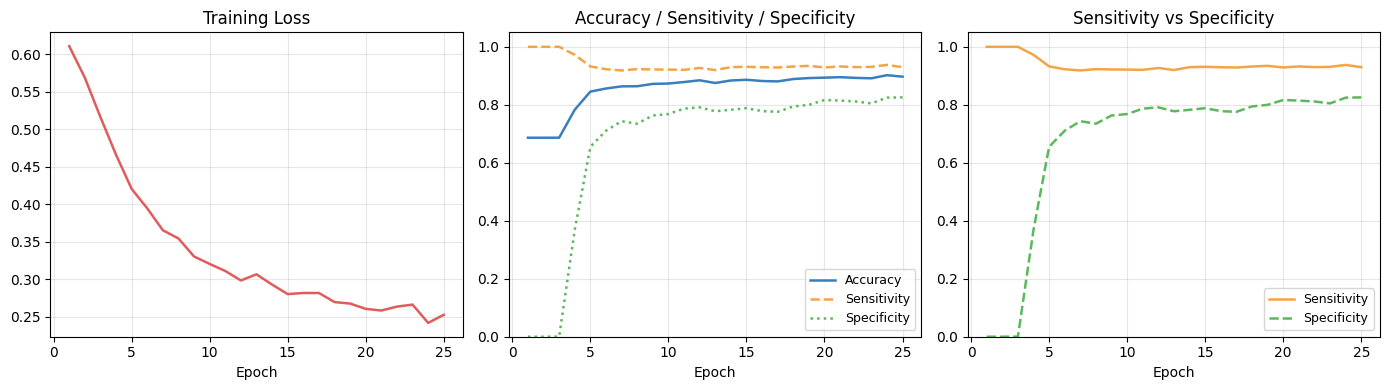

Training curves saved → training_curves.png


In [18]:
import torch
import torch.nn as nn
import random
import numpy as np
import torch

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(0)

model = HQCNN_EfficientNet_Quantum_ZNE(
    num_classes=NUM_CLASSES,
    n_qubits=NUM_QUBITS,
    n_layers=NUM_LAYERS,
    freeze_backbone=True,
    base_depol=0.0,                 
    noise_type="depolarizing",
    use_shots=False              
).to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
)
criterion = nn.CrossEntropyLoss()

EPOCHS = 25
model.train()

history = {"loss": [], "acc": [], "sensitivity": [], "specificity": []}

print(f"{'Epoch':>5} {'Loss':>8} {'Acc':>7} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 50)

for epoch in range(EPOCHS):
    loss_avg, acc, sens, spec = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    history["loss"].append(loss_avg)
    history["acc"].append(acc)
    history["sensitivity"].append(sens)
    history["specificity"].append(spec)
    print(f"{epoch+1:>5} {loss_avg:>8.4f} {acc:>7.4f} {sens:>12.4f} {spec:>12.4f}")

torch.save(model.state_dict(), "qtl_pretrained.pt")
print("\nPretrained QTL model saved → qtl_pretrained.pt")

# ── Plot training curves ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history["loss"], color="#e05c5c", linewidth=1.8)
axes[0].set_title("Training Loss");  axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["acc"],         label="Accuracy",    color="#3a7ebf", linewidth=1.8)
axes[1].plot(epochs_x, history["sensitivity"], label="Sensitivity", color="#f4a444", linewidth=1.8, linestyle="--")
axes[1].plot(epochs_x, history["specificity"], label="Specificity", color="#5cb85c", linewidth=1.8, linestyle=":")
axes[1].set_title("Accuracy / Sensitivity / Specificity")
axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, history["sensitivity"], label="Sensitivity", color="#f4a444", linewidth=1.8)
axes[2].plot(epochs_x, history["specificity"], label="Specificity", color="#5cb85c", linewidth=1.8, linestyle="--")
axes[2].set_title("Sensitivity vs Specificity"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved → training_curves.png")

Evaluating: noise=pauli, p=0.02


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/autoray/autoray.py:1219: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)
/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/autoray/autoray.py:1219: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)


Evaluating: noise=pauli, p=0.15


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/autoray/autoray.py:1219: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)
/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/autoray/autoray.py:1219: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)


Evaluating: noise=pauli, p=0.25


...

Evaluating: noise=depolarizing, p=0.15


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Evaluating: noise=depolarizing, p=0.25


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Saved sweep results → quantum_sweep_results/qtl_sweep_results.csv


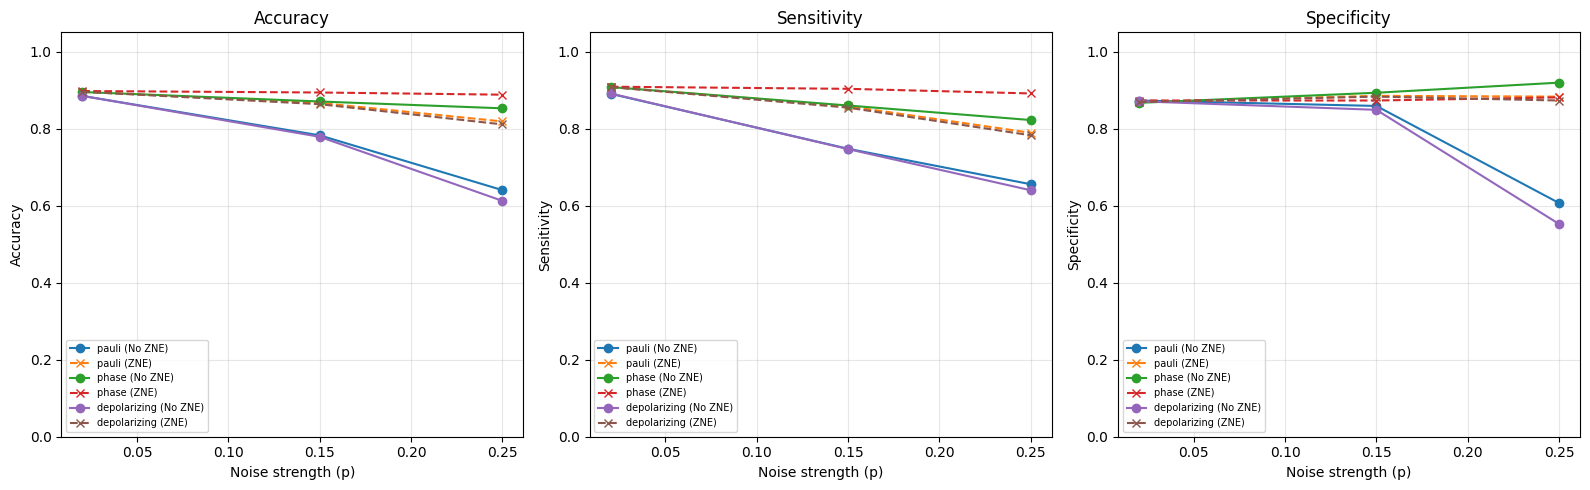


=== Sweep Summary ===
  noise_type  noise_strength  accuracy_no_zne  sensitivity_no_zne  specificity_no_zne  f1_no_zne  roc_auc_no_zne  accuracy_zne  sensitivity_zne  specificity_zne   f1_zne  roc_auc_zne  zne_gain
       pauli            0.02         0.884956            0.890424            0.872984   0.913989        0.942425      0.895702         0.907919         0.868952 0.922789     0.946717  0.010746
       pauli            0.15         0.782554            0.747698            0.858871   0.825203        0.865887      0.866625         0.858195         0.885081 0.898313     0.939912  0.084071
       pauli            0.25         0.640329            0.655617            0.606855   0.714501        0.671527      0.818584         0.789134         0.883065 0.856572     0.904776  0.178255
       phase            0.02         0.895070            0.907919            0.866935   0.922357        0.943935      0.897598         0.908840         0.872984 0.924157     0.947349  0.002528
       phase

,noise_type,noise_strength,accuracy_no_zne,precision_no_zne,sensitivity_no_zne,f1_no_zne,specificity_no_zne,roc_auc_no_zne,accuracy_zne,precision_zne,sensitivity_zne,f1_zne,specificity_zne,roc_auc_zne,zne_gain
0,pauli,0.02,0.884956,0.938835,0.890424,0.913989,0.872984,0.942425,0.895702,0.938154,0.907919,0.922789,0.868952,0.946717,0.010746
1,pauli,0.15,0.782554,0.920635,0.747698,0.825203,0.858871,0.865887,0.866625,0.942366,0.858195,0.898313,0.885081,0.939912,0.084071
2,pauli,0.25,0.640329,0.785006,0.655617,0.714501,0.606855,0.671527,0.818584,0.936612,0.789134,0.856572,0.883065,0.904776,0.178255
3,phase,0.02,0.895070,0.937262,0.907919,0.922357,0.866935,0.943935,0.897598,0.940000,0.908840,0.924157,0.872984,0.947349,0.002528
4,phase,0.15,0.870417,0.946302,0.860037,0.901110,0.893145,0.938250,0.893805,0.939655,0.903315,0.921127,0.872984,0.945763,0.023388


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ---------------- CONFIG ----------------
SWEEP_NOISE_TYPES     = ["pauli", "phase", "depolarizing"]
SWEEP_NOISE_STRENGTHS = [0.02, 0.15, 0.25]
SWEEP_SEEDS           = [0]
EVAL_SHOTS = 1000

OUT_DIR = Path("quantum_sweep_results")
OUT_DIR.mkdir(exist_ok=True)

CSV_PATH  = OUT_DIR / "qtl_sweep_results.csv"
PLOT_PATH = OUT_DIR / "qtl_sweep_plot.png"


# ---------------- METRICS ----------------
def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return tn / (tn + fp + 1e-8)


def evaluate_with_metrics(model, loader, device, zne=False):
    model.eval()
    logits_all, labels_all = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs, zne=zne)
            logits_all.append(outputs.cpu())
            labels_all.append(labels.cpu())

    logits = torch.cat(logits_all).numpy()
    y_true = torch.cat(labels_all).numpy()
    y_pred = np.argmax(logits, axis=1)
    probs  = torch.softmax(torch.tensor(logits), dim=1).numpy()

    return {
        "accuracy":    accuracy_score(y_true, y_pred),
        "precision":   precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),   # recall = sensitivity (TPR)
        "f1":          f1_score(y_true, y_pred, zero_division=0),
        "specificity": compute_specificity(y_true, y_pred),
        "roc_auc":     roc_auc_score(y_true, probs[:, 1])
    }


def run_sweep():
    rows = []

    for noise_type in SWEEP_NOISE_TYPES:
        for noise_strength in SWEEP_NOISE_STRENGTHS:
            for seed in SWEEP_SEEDS:

                print(f"Evaluating: noise={noise_type}, p={noise_strength}")
                set_seed(seed)

                # -------- Load pretrained model --------
                model = HQCNN_EfficientNet_Quantum_ZNE(
                    num_classes=NUM_CLASSES,
                    n_qubits=NUM_QUBITS,
                    n_layers=NUM_LAYERS,
                    freeze_backbone=True,
                    base_depol=noise_strength,
                    noise_type=noise_type,
                    use_shots=True
                ).to(DEVICE)

                model.load_state_dict(
                    torch.load("qtl_pretrained.pt", map_location=DEVICE)
                )

                model.quantum.shots = EVAL_SHOTS
                model.eval()

                # -------- Evaluate --------
                m_no_zne = evaluate_with_metrics(model, val_loader, DEVICE, zne=False)
                m_zne    = evaluate_with_metrics(model, val_loader, DEVICE, zne=True)

                rows.append({
                    "noise_type": noise_type,
                    "noise_strength": noise_strength,
                    **{f"{k}_no_zne": v for k, v in m_no_zne.items()},
                    **{f"{k}_zne": v for k, v in m_zne.items()},
                    "zne_gain": m_zne["accuracy"] - m_no_zne["accuracy"]
                })

    df = pd.DataFrame(rows)
    df.to_csv(CSV_PATH, index=False)
    print("Saved sweep results →", CSV_PATH)

    # -------- Plot: Accuracy, Sensitivity, Specificity --------
    metrics_to_plot = [
        ("accuracy",    "Accuracy"),
        ("sensitivity", "Sensitivity"),
        ("specificity", "Specificity"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

    for ax, (metric, title) in zip(axes, metrics_to_plot):
        for noise in SWEEP_NOISE_TYPES:
            sub = df[df["noise_type"] == noise]
            ax.plot(sub["noise_strength"], sub[f"{metric}_no_zne"],
                    "-o", label=f"{noise} (No ZNE)")
            ax.plot(sub["noise_strength"], sub[f"{metric}_zne"],
                    "--x", label=f"{noise} (ZNE)")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Noise strength (p)")
        ax.set_ylabel(title)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)

    plt.tight_layout()
    plot_path_full = OUT_DIR / "qtl_sweep_plot_full.png"
    plt.savefig(plot_path_full, dpi=300, bbox_inches="tight")
    plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")   # keep original path too
    plt.show()

    # -------- Summary table --------
    summary_cols = ["noise_type", "noise_strength",
                    "accuracy_no_zne", "sensitivity_no_zne", "specificity_no_zne",
                    "f1_no_zne",       "roc_auc_no_zne",
                    "accuracy_zne",    "sensitivity_zne",    "specificity_zne",
                    "f1_zne",          "roc_auc_zne",
                    "zne_gain"]
    print("\n=== Sweep Summary ===")
    print(df[summary_cols].to_string(index=False))

    return df


df_sweep = run_sweep()
df_sweep.head()


## Expressivity Analysis: KL Divergence vs Haar (Porter-Thomas) Distribution

This section measures **circuit expressivity** using the Kullback-Leibler (KL) divergence
between the empirical fidelity distribution (obtained by sampling random parameter sets)
and the theoretical Haar-random (Porter-Thomas) target distribution.

**Interpretation:**
- Lower KL divergence → circuit is more expressive (closer to Haar-random)
- Higher KL divergence → circuit is less expressive (biased toward certain states)
- A perfectly expressive circuit achieves KL ≈ 0

**Reference:** Sim et al., "Expressibility and Entangling Capability of Parameterized Quantum Circuits for Hybrid Quantum-Classical Algorithms" (2019)

Sampling 200 random parameter sets ...
Done.
Computing pairwise fidelities ...
Total pairs: 19900

Expressivity (KL divergence from Haar): 0.014838
  → Lower KL = more expressive (closer to Haar-random)


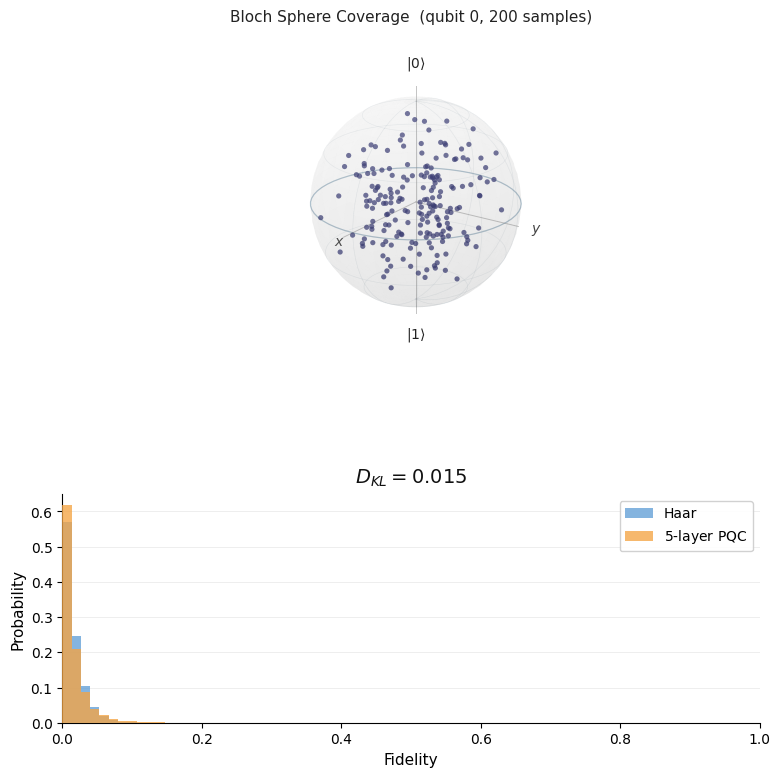

Plot saved → expressivity_kl_haar.png

  EXPRESSIVITY SUMMARY
  Circuit          : 5-layer PQC  (6 qubits)
  Hilbert dim  (N) : 64
  Samples          : 200
  Fidelity pairs   : 19,900
  KL divergence    : 0.014838
  Expressivity     : High  (KL < 0.05 → High, < 0.20 → Medium)


In [20]:
# =============================================================
# EXPRESSIVITY ANALYSIS: KL Divergence vs Haar Distribution
# =============================================================
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from scipy.stats import entropy

# ── CONFIG ────────────────────────────────────────────────────
N_QUBITS      = NUM_QUBITS
DEPTH         = NUM_LAYERS
N_SAMPLES     = 200
N_BINS        = 75
EXPRESSIVITY_X = np.zeros(N_QUBITS)

# ── DEVICE & QNODE ───────────────────────────────────────────
dev_expr = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_expr)
def pqc_state(theta, x):
    # Hadamard initialisation — matches QuantumLayerZNE._make_qnode
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)

    qml.AngleEmbedding(np.tanh(x) * np.pi, wires=range(N_QUBITS), rotation='Y')

    for l in range(DEPTH):
        # Brick-wall alternating entanglement — matches the model circuit
        if l % 2 == 0:
            pairs = [(i, i + 1) for i in range(0, N_QUBITS - 1, 2)]
        else:
            pairs = [(i, i + 1) for i in range(1, N_QUBITS - 1, 2)]
        for (i, j) in pairs:
            qml.CNOT(wires=[i, j])

        for i in range(N_QUBITS):
            qml.RX(theta[l, i, 0], wires=i)
            qml.RY(theta[l, i, 1], wires=i)
            qml.RZ(theta[l, i, 2], wires=i)

    return qml.state()

# ── SAMPLE RANDOM STATES ─────────────────────────────────────
print(f"Sampling {N_SAMPLES} random parameter sets ...")
states = []
for _ in range(N_SAMPLES):
    theta = np.random.uniform(0, 2 * np.pi, (DEPTH, N_QUBITS, 3))
    psi   = np.array(pqc_state(theta, EXPRESSIVITY_X))
    states.append(psi)
print("Done.")

# ── COMPUTE PAIRWISE FIDELITIES ───────────────────────────────
print("Computing pairwise fidelities ...")
fidelities = []
for i in range(N_SAMPLES):
    for j in range(i + 1, N_SAMPLES):
        F = abs(np.dot(states[i].conj(), states[j])) ** 2
        fidelities.append(float(np.clip(F, 0.0, 1.0)))
fidelities = np.array(fidelities)
print(f"Total pairs: {len(fidelities)}")

# ── EMPIRICAL FIDELITY DISTRIBUTION ──────────────────────────
counts, bin_edges = np.histogram(fidelities, bins=N_BINS, range=(0, 1))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
p_empirical = counts / counts.sum()

# ── HAAR / PORTER-THOMAS TARGET ──────────────────────────────
N_DIM  = 2 ** N_QUBITS
p_haar = (N_DIM - 1) * (1 - bin_centers) ** (N_DIM - 2)
p_haar = p_haar / p_haar.sum()

# ── KL DIVERGENCE ─────────────────────────────────────────────
EPS    = 1e-12
kl_div = entropy(p_empirical + EPS, p_haar + EPS)
print(f"\nExpressivity (KL divergence from Haar): {kl_div:.6f}")
print("  → Lower KL = more expressive (closer to Haar-random)")

# ── PARTIAL TRACE: qubit 0 density matrix (FIXED) ────────────
def state_to_bloch_qubit0(psi, n_qubits):
    """Partial trace over qubits 1…n-1, returns 2x2 density matrix for qubit 0."""
    dim_rest = 2 ** (n_qubits - 1)
    psi_r    = psi.reshape(2, dim_rest)   # (2, 2^(n-1))
    rho_q0   = psi_r @ psi_r.conj().T    # (2, 2)  — correct for any n_qubits
    return rho_q0

def dm_to_bloch(rho):
    X = np.array([[0, 1],  [1,  0]])
    Y = np.array([[0, -1j],[1j, 0]])
    Z = np.array([[1, 0],  [0, -1]])
    return [
        float(np.real(np.trace(rho @ X))),
        float(np.real(np.trace(rho @ Y))),
        float(np.real(np.trace(rho @ Z))),
    ]

bloch_vecs = [dm_to_bloch(state_to_bloch_qubit0(s, N_QUBITS)) for s in states]  # all samples

# ── PLOT  (paper-style: Bloch sphere above, KL histogram below) ──────────
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── helper: draw a clean Bloch sphere shell ─────────────────────────────
def _draw_sphere_shell(ax, *, alpha_wire=0.18, lw=0.45):
    """Latitude / longitude wireframe + equator + |0⟩|1⟩ / x / y labels."""
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    # Faint surface tint
    ax.plot_surface(xs, ys, zs, color='#e8e8e8', alpha=0.08, linewidth=0)

    # Latitude lines
    for lat in np.linspace(-np.pi/2, np.pi/2, 7):
        r = np.cos(lat)
        z = np.sin(lat)
        ax.plot(r*np.cos(u), r*np.sin(u), np.full_like(u, z),
                color='#9aacb8', linewidth=lw, alpha=alpha_wire)

    # Longitude lines
    for lon in np.linspace(0, np.pi, 6):
        ax.plot(np.sin(v)*np.cos(lon), np.sin(v)*np.sin(lon), np.cos(v),
                color='#9aacb8', linewidth=lw, alpha=alpha_wire)

    # Bold equator
    ax.plot(np.cos(u), np.sin(u), np.zeros_like(u),
            color='#7a9ab0', linewidth=0.9, alpha=0.55)

    # Axis stubs
    stub = 1.15
    ax.plot([0, stub], [0, 0], [0, 0], color='#888', linewidth=0.7, alpha=0.5)
    ax.plot([0, 0], [0, stub], [0, 0], color='#888', linewidth=0.7, alpha=0.5)
    ax.plot([0, 0], [0, 0], [-stub, stub], color='#888', linewidth=0.7, alpha=0.5)

    # Labels — match the paper (|0⟩ top, |1⟩ bottom, x / y on equator)
    offset = 1.28
    ax.text(0, 0,  offset, '$|0\\rangle$', ha='center', va='bottom', fontsize=10,
            color='#222', fontweight='normal')
    ax.text(0, 0, -offset, '$|1\\rangle$', ha='center', va='top',    fontsize=10,
            color='#222', fontweight='normal')
    ax.text(offset, 0, 0,  '$x$',           ha='left',   va='center', fontsize=10,
            color='#444', style='italic')
    ax.text(0, offset, 0,  '$y$',           ha='left',   va='center', fontsize=10,
            color='#444', style='italic')

# ── figure layout ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 9))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.55, 1],
                         hspace=0.38)

# ══════════════════════════════════════════════════════
# TOP PANEL — 3-D Bloch sphere (paper style)
# ══════════════════════════════════════════════════════
ax_bloch = fig.add_subplot(gs[0], projection='3d')

_draw_sphere_shell(ax_bloch)

bx = np.array([v[0] for v in bloch_vecs])
by = np.array([v[1] for v in bloch_vecs])
bz = np.array([v[2] for v in bloch_vecs])

# Scatter: dark indigo dots, identical to Circuit-B / Arbitrary-unitary panels
ax_bloch.scatter(
    bx, by, bz,
    c='#2d2f6e',           # deep indigo — matches the paper colour
    s=14,
    alpha=0.72,
    edgecolors='none',
    depthshade=True,
    zorder=6,
)

# Cosmetics
ax_bloch.set_xlim(-1, 1); ax_bloch.set_ylim(-1, 1); ax_bloch.set_zlim(-1, 1)
ax_bloch.set_box_aspect([1, 1, 1])
ax_bloch.set_axis_off()
ax_bloch.set_title(
    f'Bloch Sphere Coverage  (qubit 0, {len(bloch_vecs)} samples)',
    fontsize=11, pad=6, color='#222'
)
ax_bloch.view_init(elev=20, azim=35)   # view angle matching the paper

# ══════════════════════════════════════════════════════
# BOTTOM PANEL — fidelity histogram vs Haar
# ══════════════════════════════════════════════════════
ax_hist = fig.add_subplot(gs[1])

bar_w = 1.0 / N_BINS

# Haar — blue (semi-transparent, drawn first so PQC sits on top)
ax_hist.bar(bin_centers, p_haar,
            width=bar_w, color='#5b9bd5', alpha=0.75,
            label='Haar', zorder=2)

# PQC empirical — orange
ax_hist.bar(bin_centers, p_empirical,
            width=bar_w, color='#f4a444', alpha=0.78,
            label=r'$5$-layer PQC', zorder=3)

ax_hist.set_xlim(0, 1)
ax_hist.set_xlabel('Fidelity', fontsize=11)
ax_hist.set_ylabel('Probability', fontsize=11)
ax_hist.set_title(
    rf'$D_{{KL}} = {kl_div:.3f}$',
    fontsize=14, fontweight='normal', color='#111', pad=8
)
ax_hist.legend(fontsize=10, framealpha=0.9)
ax_hist.spines[['top', 'right']].set_visible(False)
ax_hist.tick_params(axis='both', labelsize=10)
ax_hist.grid(axis='y', alpha=0.25, linewidth=0.6)

plt.savefig('expressivity_kl_haar.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Plot saved → expressivity_kl_haar.png')

# ── SUMMARY ───────────────────────────────────────────────────
print('\n' + '='*50)
print('  EXPRESSIVITY SUMMARY')
print('='*50)
print(f'  Circuit          : {DEPTH}-layer PQC  ({N_QUBITS} qubits)')
print(f'  Hilbert dim  (N) : {N_DIM}')
print(f'  Samples          : {N_SAMPLES}')
print(f'  Fidelity pairs   : {len(fidelities):,}')
print(f'  KL divergence    : {kl_div:.6f}')
qual = 'High' if kl_div < 0.05 else ('Medium' if kl_div < 0.20 else 'Low')
print(f'  Expressivity     : {qual}  (KL < 0.05 → High, < 0.20 → Medium)')
print('='*50)